In [8]:
import os
import time
import random
import timm
import torchvision
from torchvision import datasets, transforms
import torchvision.models as models
import torch
import torch.nn as nn
import torch.nn.functional as F

def seed_all(seed=123):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

batch_size = 64
seed = 123
seed_all(seed)

temperature=0.07

pretrain_epochs = 200
finetune_epochs = 50

num_class = 3

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
print(torch.cuda.is_available())
print(torch.__version__)
print(torch.version.cuda)

True
2.11.0+cu128
12.8


In [10]:
from pathlib import Path
from typing import List, Sequence, Optional
from PIL import Image, ImageOps
from torch.utils.data import Dataset
from torchvision import transforms
from torchvision.transforms import functional as TF

class Clsdata(Dataset):
    def __init__(
        self,
        root_list: Sequence[str], # front images path list
        cls_to_idx,
        shuffle: bool = True,
        transform=None,
        train: bool = False,
        test: bool = False,
        img_size: int = 224,
    ):
        assert not (train and test), "Both train and test cannot be True at the same time"
        self.test = test
        self.train = train
        self.img_size = int(img_size)

        lines: List[Path] = [Path(p) for p in root_list]
        if shuffle:
            random.shuffle(lines)
        self.lines = lines
        self.nSamples = len(self.lines)

        self.mean = (0.485, 0.456, 0.406)
        self.std  = (0.229, 0.224, 0.225)

        if transform is None:
            if self.train and not self.test:
                self.transform = None
            else:
                # val / test：
                self.transform = transforms.Compose([
                    transforms.Resize((self.img_size, self.img_size)),
                    transforms.ToTensor(),
                    transforms.Normalize(self.mean, self.std),
                ])
        else:
            self.transform = transform

        self.cls_to_idx = cls_to_idx
        self.idx_to_cls = {v: k for k, v in self.cls_to_idx.items()}

    def __len__(self):
        return self.nSamples

    def _pair_transform(self, img1_pil: Image.Image, img2_pil: Image.Image):
        img1 = ImageOps.exif_transpose(img1_pil)
        img2 = ImageOps.exif_transpose(img2_pil)

        img1 = TF.resize(img1, [self.img_size, self.img_size])
        img2 = TF.resize(img2, [self.img_size, self.img_size])

        if random.random() < 0.5:
            img1 = TF.hflip(img1)
            img2 = TF.hflip(img2)

        if random.random() < 0.5:
            img1 = TF.vflip(img1)
            img2 = TF.vflip(img2)

        if random.random() < 0.8:
            b = 1.0 + random.uniform(-0.2, 0.2)  # brightness factor
            c = 1.0 + random.uniform(-0.2, 0.2)  # contrast factor
            s = 1.0 + random.uniform(-0.2, 0.2)  # saturation factor
            h = random.uniform(-0.05, 0.05)      # hue delta

            img1 = TF.adjust_brightness(img1, b); img2 = TF.adjust_brightness(img2, b)
            img1 = TF.adjust_contrast(img1, c);   img2 = TF.adjust_contrast(img2, c)
            img1 = TF.adjust_saturation(img1, s); img2 = TF.adjust_saturation(img2, s)
            img1 = TF.adjust_hue(img1, h);        img2 = TF.adjust_hue(img2, h)


        # ToTensor + Normalize
        img1 = TF.to_tensor(img1); img2 = TF.to_tensor(img2)
        img1 = TF.normalize(img1, self.mean, self.std)
        img2 = TF.normalize(img2, self.mean, self.std)
        return img1, img2

    def __getitem__(self, index: int):
        assert 0 <= index < len(self), f'index out of range: {index} / {len(self)}'

        img_path = self.lines[index]
        # front / side
        img1_path = img_path
        img2_path = Path(str(img_path).replace("front.jpg", "side.jpg"))

        img1_pil = Image.open(img1_path).convert('RGB')
        img2_pil = Image.open(img2_path).convert('RGB')

        if self.train and not self.test and self.transform is None:
            img1, img2 = self._pair_transform(img1_pil, img2_pil)
        else:
            img1  = self.transform(img1_pil)
            img2 = self.transform(img2_pil)

        class_name = Path(img_path).parent.parent.name
        label = self.cls_to_idx[class_name]

        return img1, img2, label

In [11]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

train_root = r"/home/airl02/Desktop/ParkJeongEun/PediURF/train"
test_root = r"/home/airl02/Desktop/ParkJeongEun/PediURF/test"

cls_to_idx = {
    "Proximal ulna and radius fractures": 0,
    "Midshaft ulna and radius fractures": 1,
    "Distal ulna and radius fractures": 2,
}

def get_all_imgs_path(root: str):
  root = Path(root)
  all_front_path = [str(p) for p in root.rglob("front.jpg")]
  return all_front_path

def get_label_from_path(img_path: str):
  path = Path(img_path)
  class_name = path.parent.parent.name

  if class_name not in cls_to_idx:
    raise ValueError(f"Unknown class folder name: {class_name}")

  return cls_to_idx[class_name]

def make_stratified_split(train_root, val_ratio=0.2, seed=123):
  all_imgs_path = get_all_imgs_path(train_root)

  all_labels = [get_label_from_path(p) for p in all_imgs_path]

  train_imgs_path, val_imgs_path = train_test_split(
      all_imgs_path,
      test_size=val_ratio,
      random_state=seed,
      stratify=all_labels
  )

  return train_imgs_path, val_imgs_path

train_imgs_path, val_imgs_path = make_stratified_split(
    train_root = train_root,
    val_ratio=0.2,
    seed=seed
)

test_imgs_path = get_all_imgs_path(test_root)

pre_train_data = Clsdata(train_imgs_path, cls_to_idx, train=True, shuffle=True)
pre_val_data  = Clsdata(val_imgs_path, cls_to_idx, train=False, shuffle=False, test=True)
pre_test_data = Clsdata(test_imgs_path, cls_to_idx, train=False, shuffle=False, test=True)

pre_train_loader = DataLoader(pre_train_data, batch_size=batch_size, shuffle=True, num_workers=2)
pre_val_loader = DataLoader(pre_val_data, batch_size=batch_size, shuffle=False, num_workers=2)
pre_test_loader = DataLoader(pre_test_data, batch_size=batch_size, shuffle=False, num_workers=2)

train_length = len(pre_train_data)
val_length  = len(pre_val_data)
test_length = len(pre_test_data)

print(f"train_length: {train_length}")
print(f"val_length: {val_length}")
print(f"test_length: {test_length}")

train_length: 3369
val_length: 843
test_length: 1053


In [12]:
from torchvision.models import ResNet34_Weights

class SupConBackbone(nn.Module):
    def __init__(self, proj_dim=128):
        super(SupConBackbone, self).__init__()

        # Backbone: 공통 특징 추출기
        self.encoder = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
        self.encoder.fc = nn.Identity()

        # Projection Head: 이 공간에서만 Contrastive Learning 수행
        self.projection_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, proj_dim)
        )

    def forward(self, x1, x2):
        features1 = self.encoder(x1)
        features2 = self.encoder(x2)

        z1 = F.normalize(self.projection_head(features1))
        z2 = F.normalize(self.projection_head(features2))

        return z1, z2

pretrain_model = SupConBackbone().to(device)

In [13]:
class SupConLoss(nn.Module):
  def __init__(self, temperature):
    super().__init__()
    self.temperature = temperature

  def forward(self, features, labels):
    """
    features: [B, 2, dim] (z1 + z2)
    labels: [B] # labels가 같으면 positive
    """
    device = features.device
    batch_size = features.shape[0]

    # 2개의 view를 하나로 펼침 [2*B, dim]
    # 이렇게 하면 (환자1_view1, 환자1_view2, 환자2_view1, 환자2_view2...) 순서가 됨
    features = F.normalize(features, dim=2) # 벡터 길이를 1로 맞춤
    features = features.view(batch_size * 2, -1)

    # 라벨도 2배로 늘림 [2*B]
    # labels는 (환자1_label, 환자1_label, 환자2_label, 환자2_label...)
    labels = labels.repeat_interleave(2)

    # 메모리에서 데이터 재정렬하고, 컬럼 형태로 shape 조정
    labels = labels.contiguous().view(-1, 1)

    # Mask 생성: 라벨이 같으면 1 (동일 환자의 다른 뷰 + 동일 클래스의 다른 환자)
    mask = torch.eq(labels, labels.T).float().to(device)

    # 학습에 도움이 안 되는 자기 자신과의 유사도는 제외 (지정각 행렬 0 처리)
    logits_mask = torch.scatter(
        torch.ones_like(mask), # 전체 1 적용
        1, # 가로 방향으로 이동 (column-wise)
        torch.arange(batch_size * 2).view(-1, 1).to(device), # 각 사진의 번호 매김 (0 ~ n-1)
        0 # 그 좌표에 0을 넣음
    )
    mask = mask * logits_mask

    # 유사도 계산: 1 ~ -1 (1이 최대 유사도)
    # temperature는 "확실히 닮은 것"에 예민하게 반응하도록 조절
    logits = torch.matmul(features, features.T) / self.temperature

    # 수치적 안정화 (Log-Sum-Exp): 점수판에서 가장 큰 숫자 빼서 overflow 방지
    logits_max, _ = torch.max(logits, dim=1, keepdim=True)
    logits = logits - logits_max.detach()

    # Loss 계산
    exp_logits = torch.exp(logits) * logits_mask # 실제 mask 적용되는 부분
    log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True) + 1e-6) # 각 행별로 "나를 제외한 나머지 모든 사진과의 유사도 합계"

    # 같은 클래스(및 동일환자 뷰)인 경우의 log_prob 평균
    mean_log_prob_pos = (mask * log_prob).sum(1) / (mask.sum(1) + 1e-6)

    loss = -mean_log_prob_pos.mean()
    return loss


In [14]:
from sklearn.metrics import f1_score
from datetime import datetime
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

model_dir = "/home/airl02/Desktop/ParkJeongEun/Model"

learning_rate = 1e-3

criterion_supcon = SupConLoss(temperature)
optimizer_supcon = torch.optim.SGD(pretrain_model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=1e-4)
scheduler_supcon = CosineAnnealingWarmRestarts(optimizer_supcon, T_0=50, T_mult=1, eta_min=1e-6)

train_losses, val_losses = [], []

start_epoch = 0

for epoch in range(start_epoch, pretrain_epochs):
  pretrain_model.train()
  total_train_loss = 0.0

  for img1, img2, label in pre_train_loader:
    img1 = img1.to(device)
    img2 = img2.to(device)
    label = label.to(device)

    optimizer_supcon.zero_grad()

    z1, z2 = pretrain_model(img1, img2)

    z_stacked = torch.stack([z1, z2], dim=1)
    loss = criterion_supcon(z_stacked, label)

    loss.backward()
    optimizer_supcon.step()

    total_train_loss += loss.item() * img1.size(0)

  train_loss = total_train_loss / train_length
  train_losses.append(train_loss)

  scheduler_supcon.step()

  pretrain_model.eval()
  total_val_loss = 0.0

  with torch.no_grad():
    for img1, img2, label in pre_val_loader:
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)

        z1, z2 = pretrain_model(img1, img2)

        z_stacked = torch.stack([z1, z2], dim=1)
        loss = criterion_supcon(z_stacked, label)

        total_val_loss += loss.item() * img1.size(0)

  val_loss = total_val_loss / val_length
  val_losses.append(val_loss)

  print(f"[{datetime.now().strftime('%H:%M:%S')}] Epoch [{epoch+1}/{pretrain_epochs}]"
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

  if (epoch + 1) % 50 == 0:
      checkpoint_path = os.path.join(model_dir, f"ResNet34_SupCon_Cycle_{epoch+1}.pth")
      torch.save({
          'epoch': epoch,
          'model_state_dict': pretrain_model.state_dict(),
      }, checkpoint_path)

[18:03:35] Epoch [1/200]Train Loss: 4.8786 | Val Loss: 4.8254
[18:04:32] Epoch [2/200]Train Loss: 4.8420 | Val Loss: 4.8231
[18:05:31] Epoch [3/200]Train Loss: 4.8398 | Val Loss: 4.8221
[18:06:25] Epoch [4/200]Train Loss: 4.8387 | Val Loss: 4.8211
[18:07:19] Epoch [5/200]Train Loss: 4.8376 | Val Loss: 4.8200
[18:08:12] Epoch [6/200]Train Loss: 4.8354 | Val Loss: 4.8185
[18:09:07] Epoch [7/200]Train Loss: 4.8321 | Val Loss: 4.8148
[18:10:02] Epoch [8/200]Train Loss: 4.8257 | Val Loss: 4.8077
[18:10:59] Epoch [9/200]Train Loss: 4.8081 | Val Loss: 4.7855
[18:11:56] Epoch [10/200]Train Loss: 4.7630 | Val Loss: 4.7499
[18:12:50] Epoch [11/200]Train Loss: 4.7070 | Val Loss: 4.7051
[18:13:44] Epoch [12/200]Train Loss: 4.6451 | Val Loss: 4.6880
[18:14:37] Epoch [13/200]Train Loss: 4.6167 | Val Loss: 4.6699
[18:15:32] Epoch [14/200]Train Loss: 4.5912 | Val Loss: 4.6629
[18:16:27] Epoch [15/200]Train Loss: 4.5719 | Val Loss: 4.6566
[18:17:23] Epoch [16/200]Train Loss: 4.5476 | Val Loss: 4.6385
[

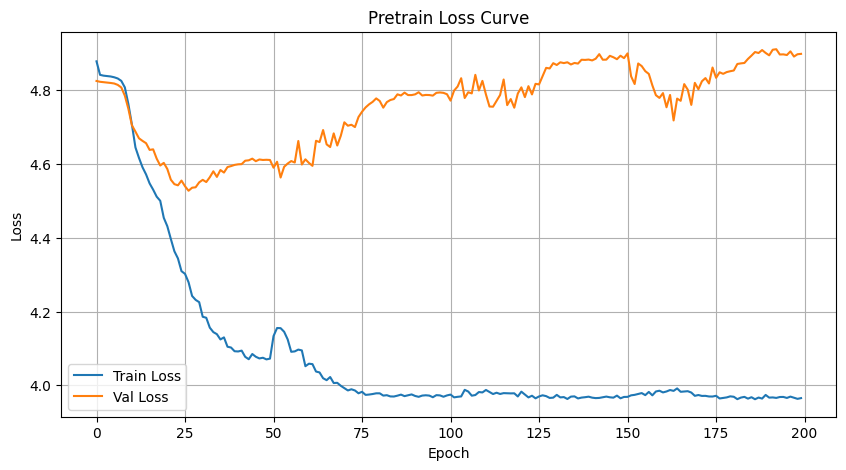

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Pretrain Loss Curve")
plt.legend()
plt.grid(True)
plt.show()



KNN Top-1 Accuracy: 100.00%
Running t-SNE (this may take a while)...


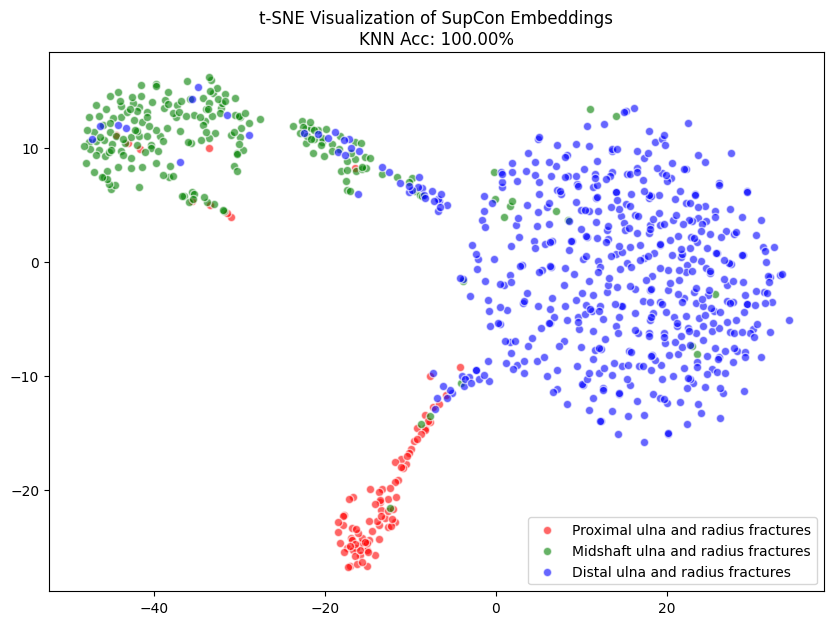

In [16]:
import numpy as np
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import torch

def evaluate_embeddings(pretrain_model, val_loader, device):
    pretrain_model.eval()
    targets_list = []
    embeddings_list = []

    with torch.no_grad():
        for img1, img2, label in val_loader:
            img1, img2 = img1.to(device), img2.to(device)

            # 모델의 forward 구조에 따라 수정 (z1, z2를 얻음)
            z1, z2 = pretrain_model(img1, img2)

            # 두 뷰의 특징을 평균내거나 하나만 사용 (여기서는 평균 사용)
            z_avg = (z1 + z2) / 2

            embeddings_list.append(z_avg.cpu().numpy())
            targets_list.append(label.numpy())

    embeddings = np.concatenate(embeddings_list, axis=0)
    targets = np.concatenate(targets_list, axis=0)

    # 1. KNN Accuracy 계산 (1-Nearest Neighbor)
    # 데이터를 반으로 나눠서 학습/테스트로 시뮬레이션하거나 전체로 적합도 확인
    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(embeddings, targets)
    knn_acc = knn.score(embeddings, targets)
    print(f"KNN Top-1 Accuracy: {knn_acc*100:.2f}%")

    # 2. t-SNE 시각화
    print("Running t-SNE (this may take a while)...")
    tsne = TSNE(n_components=2, random_state=seed, init='pca', learning_rate='auto')
    tsne_results = tsne.fit_transform(embeddings)

    plt.figure(figsize=(10, 7))
    classes = list(cls_to_idx.keys())
    colors = ['r', 'g', 'b']

    for i, cls_name in enumerate(classes):
        idx = np.where(targets == i)
        plt.scatter(tsne_results[idx, 0], tsne_results[idx, 1],
                    c=colors[i], label=cls_name, alpha=0.6, edgecolors='w')

    plt.legend()
    plt.title(f"t-SNE Visualization of SupCon Embeddings\nKNN Acc: {knn_acc*100:.2f}%")
    plt.show()

evaluate_embeddings(pretrain_model, pre_val_loader, device)

In [ ]:
class SupConClassifier(nn.Module):
    def __init__(self, pretrained_path=None, num_classes=3):
        super(SupConClassifier, self).__init__()
        
        if pretrained_path is not None:
            backbone = SupConBackbone()
            checkpoint = torch.load(pretrained_path, map_location=device)
            backbone.load_state_dict(checkpoint['model_state_dict'])
            self.encoder = backbone.encoder
        else:
            self.encoder = models.resnet34(weights=None)
            self.encoder.fc = nn.Identity()

        # 3. 최종 분류기 (MLP)
        self.classifier = nn.Sequential(
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
            # 두 뷰를 융합하기 위한 최소한의 레이어만 추가
        )

    def forward(self, x1, x2):
        # 특징 추출 (x1, x2 각각)
        f1 = self.encoder(x1) # [B, 512]
        f2 = self.encoder(x2) # [B, 512]

        x = torch.cat([f1, f2], dim=1) # [B, 1024]

        logits = self.classifier(x)
        return logits

In [18]:
# 1. Stage 2용 약한 증강 (Weak Augmentation) 정의
finetune_transformer = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

# 2. Validation/Test용 (증강 아예 없음)
test_transformer = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

ft_train_data = Clsdata(train_imgs_path, cls_to_idx, train=False, transform=finetune_transformer)
ft_val_data   = Clsdata(val_imgs_path, cls_to_idx, train=False, transform=test_transformer)
ft_test_data  = Clsdata(test_imgs_path, cls_to_idx, train=False, transform=test_transformer)

ft_train_loader = DataLoader(ft_train_data, batch_size=batch_size, shuffle=True, num_workers=2)
ft_val_loader = DataLoader(ft_val_data, batch_size=batch_size, shuffle=False, num_workers=2)
ft_test_loader  = DataLoader(ft_test_data, batch_size=batch_size, shuffle=False, num_workers=2)

train_length = len(ft_train_data)
val_length  = len(ft_val_data)
test_length = len(ft_test_data)

print(f"train_length: {train_length}")
print(f"val_length: {val_length}")
print(f"test_length: {test_length}")

train_length: 3369
val_length: 843
test_length: 1053


In [19]:
import os
from datetime import datetime
from sklearn.metrics import f1_score
from torch.optim.lr_scheduler import CosineAnnealingLR

model_dir = "/home/airl02/Desktop/ParkJeongEun/Model"

checkpoint_files = [
    "ResNet34_SupCon_Cycle_50.pth",
    "ResNet34_SupCon_Cycle_100.pth",
    "ResNet34_SupCon_Cycle_150.pth",
    "ResNet34_SupCon_Cycle_200.pth"
]

for i, ckpt_name in enumerate(checkpoint_files):
    print(f"\nFine-tuning for Cycle {i+1} starts...")

    checkpoint_path = os.path.join(model_dir, ckpt_name)
    finetune_model = SupConClassifier(checkpoint_path).to(device)

    best_val_f1 = 0.0
    start_epoch = 0
    early_stop_counter = 0

    encoder_lr = 1e-6
    classifier_lr = 1e-5

    label_smoothing = 0.1
    patience = 10

    train_losses, val_losses = [], []

    params_to_optimize = [
      {'params': finetune_model.encoder.parameters(), 'lr': encoder_lr},
      {'params': finetune_model.classifier.parameters(), 'lr': classifier_lr}
    ]

    optimizer_ce = torch.optim.Adam(params_to_optimize, weight_decay=1e-2)
    scheduler_ce = CosineAnnealingLR(optimizer_ce, T_max=finetune_epochs)
    criterion_ce = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    for epoch in range(start_epoch, finetune_epochs):
      finetune_model.train()
      total_train_loss = 0.0

      for img1, img2, label in ft_train_loader:
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        optimizer_ce.zero_grad()

        logits = finetune_model(img1, img2)
        loss = criterion_ce(logits, label)
        loss.backward()
        optimizer_ce.step()

        total_train_loss += loss.item() * img1.size(0)

      train_loss = total_train_loss / train_length
      train_losses.append(train_loss)

      scheduler_ce.step()

      finetune_model.eval()
      all_preds, all_labels = [], []
      total_val_loss = 0.0

      with torch.no_grad():
        for img1, img2, label in ft_val_loader:
            img1, img2, label = img1.to(device), img2.to(device), label.to(device)
            logits = finetune_model(img1, img2)

            loss = criterion_ce(logits, label)
            total_val_loss += loss.item() * img1.size(0)

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(label.cpu().numpy())

      val_f1 = f1_score(all_labels, all_preds, average='weighted')
      val_loss = total_val_loss / val_length
      val_losses.append(val_loss)

      print(f"[{datetime.now().strftime('%H:%M:%S')}] [Epoch {epoch+1}] "
        f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val F1: {val_f1:.4f}")

      if best_val_f1 < val_f1:
          best_model_name = f"ResNet34_Best_SupCon_Cycle_{(i+1)*50}_Finetuned.pth"
          best_model_path = os.path.join(model_dir, best_model_name)

          best_val_f1 = val_f1
          early_stop_counter = 0

          torch.save({
              'epoch': epoch,
              'model_state_dict': finetune_model.state_dict(),
          }, best_model_path)

          print(f"Best model for cycle {(i+1)*50} saved! (Val F1: {best_val_f1:.4f})")

      else:
          early_stop_counter += 1

          if early_stop_counter >= patience:
            print(f"Early stopping trigerred for cycle {(i+1)*50} at epoch {epoch+1}")
            break



Fine-tuning for Cycle 1 starts...
[21:09:20] [Epoch 1] Train Loss: 0.7901, Val Loss: 0.7203, Val F1: 0.8745
Best model for cycle 50 saved! (Val F1: 0.8745)
[21:10:09] [Epoch 2] Train Loss: 0.5127, Val Loss: 0.5599, Val F1: 0.9182
Best model for cycle 50 saved! (Val F1: 0.9182)
[21:10:59] [Epoch 3] Train Loss: 0.4309, Val Loss: 0.5225, Val F1: 0.9178
[21:11:48] [Epoch 4] Train Loss: 0.3950, Val Loss: 0.4995, Val F1: 0.9222
Best model for cycle 50 saved! (Val F1: 0.9222)
[21:12:39] [Epoch 5] Train Loss: 0.3756, Val Loss: 0.4998, Val F1: 0.9220
[21:13:32] [Epoch 6] Train Loss: 0.3636, Val Loss: 0.4820, Val F1: 0.9166
[21:14:23] [Epoch 7] Train Loss: 0.3563, Val Loss: 0.4820, Val F1: 0.9239
Best model for cycle 50 saved! (Val F1: 0.9239)
[21:15:14] [Epoch 8] Train Loss: 0.3501, Val Loss: 0.4789, Val F1: 0.9202
[21:16:06] [Epoch 9] Train Loss: 0.3440, Val Loss: 0.4808, Val F1: 0.9229
[21:16:57] [Epoch 10] Train Loss: 0.3443, Val Loss: 0.4790, Val F1: 0.9227
[21:17:45] [Epoch 11] Train Loss

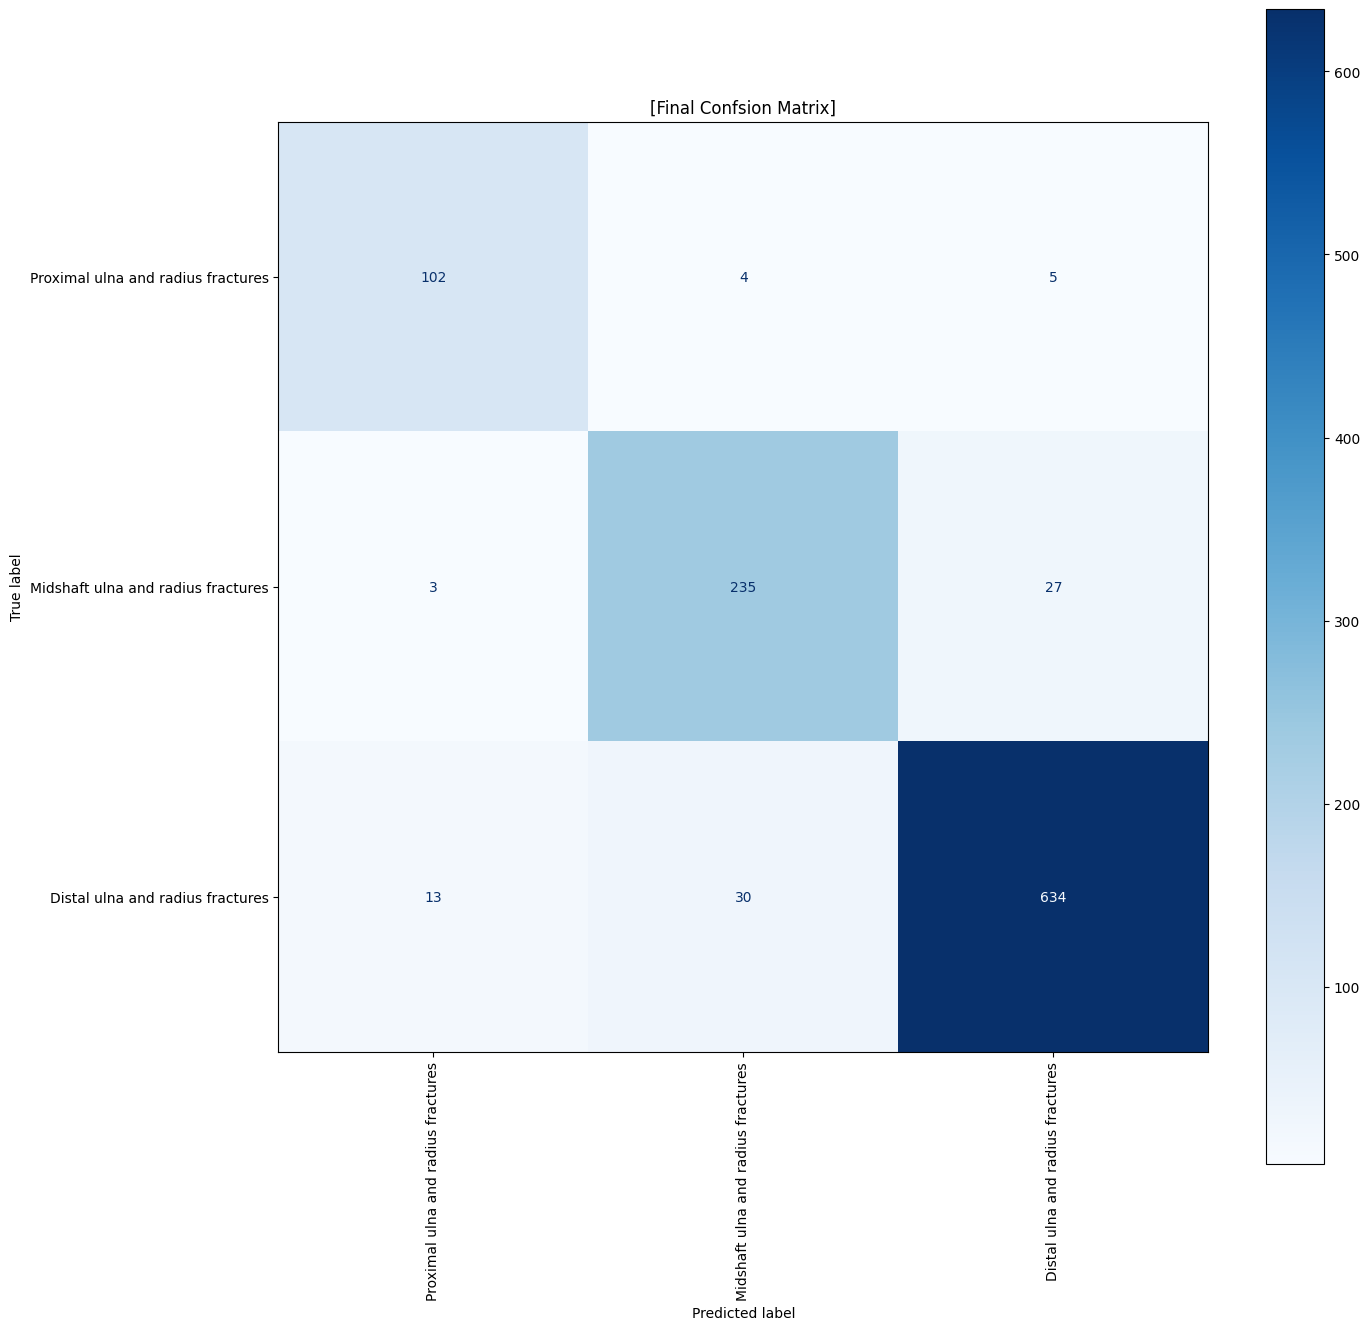


[Classification Report]
                                    precision    recall  f1-score   support

Proximal ulna and radius fractures     0.8644    0.9189    0.8908       111
Midshaft ulna and radius fractures     0.8736    0.8868    0.8801       265
  Distal ulna and radius fractures     0.9520    0.9365    0.9442       677

                          accuracy                         0.9221      1053
                         macro avg     0.8967    0.9141    0.9050      1053
                      weighted avg     0.9230    0.9221    0.9224      1053



In [20]:
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, precision_score, recall_score, f1_score,roc_auc_score, auc, roc_curve

def test_ensemble(models, test_loader):
    total_preds = []
    total_labels = []

    with torch.no_grad():
        for img1, img2, label in test_loader:
            img1, img2 = img1.to(device), img2.to(device)

            # 모든 모델의 확률값(Softmax)을 더함
            ensemble_logits = None
            for model in models:
                outputs = model(img1, img2)
                probs = F.softmax(outputs, dim=1)
                if ensemble_logits is None:
                    ensemble_logits = probs
                else:
                    ensemble_logits += probs

            # 평균 확률로 최종 클래스 결정
            preds = torch.argmax(ensemble_logits, dim=1)
            total_preds.extend(preds.cpu().numpy())
            total_labels.extend(label.numpy())

    return total_preds, total_labels

model_dir = "/home/airl02/Desktop/ParkJeongEun/Model"

best_model_files = [
    "ResNet34_Best_SupCon_Cycle_50_Finetuned.pth",
    "ResNet34_Best_SupCon_Cycle_100_Finetuned.pth",
    "ResNet34_Best_SupCon_Cycle_150_Finetuned.pth",
    "ResNet34_Best_SupCon_Cycle_200_Finetuned.pth"
]

final_models = []
for name in best_model_files:
    model = SupConClassifier().to(device)
    checkpoint = torch.load(best_model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])

    model.eval()

    final_models.append(model)

# 2. 앙상블 결과 확인
preds, labels = test_ensemble(final_models, ft_test_loader)

idx_to_cls = ft_test_data.idx_to_cls

pred_cls = [idx_to_cls[i] for i in preds]
labels_cls = [idx_to_cls[i] for i in labels]

cm = confusion_matrix(labels_cls, pred_cls, labels=list(idx_to_cls.values()))
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(idx_to_cls.values()))

fig, ax = plt.subplots(figsize=(15, 15))
display.plot(cmap='Blues', xticks_rotation='vertical', ax=ax)
plt.title("[Final Confsion Matrix]")
plt.show()

print("\n[Classification Report]")
print(classification_report(
    labels_cls,
    pred_cls,
    labels=list(idx_to_cls.values()),
    target_names=list(idx_to_cls.values()),
    digits=4,
    zero_division=0
))

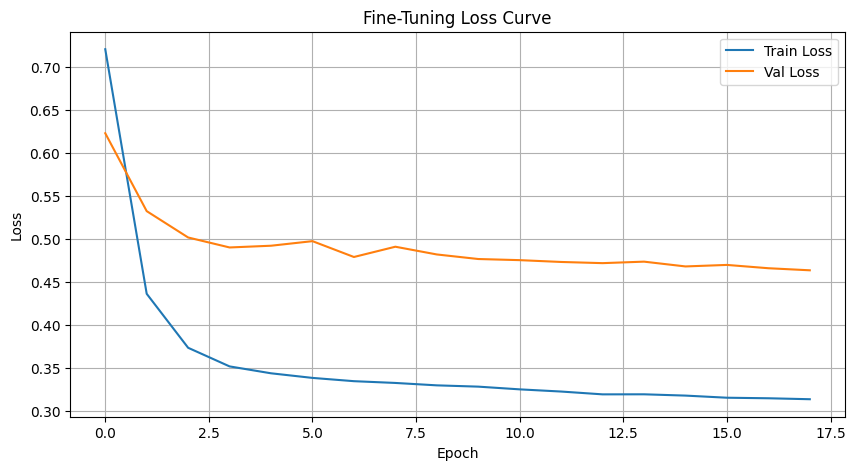

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Fine-Tuning Loss Curve")
plt.legend()
plt.grid(True)
plt.show()